In [1]:
import numpy
import math
import pandas

In [2]:
#analytical solution
#T = (4V/pi) SUM_{n=0}^{inf}[(1/(2n+1)) sin(2n+1)pi*x/a sinh(b-y)(2n+1)pi/a cosech(2n+1)pi*b/a
def get_sinh(x):
    try:
        sinh = (1-math.expm1(-2*x))/(2*math.expm1(-x))
        return sinh
    except:
        print(f"wrong", {x})
    
def getTemp_xy(x: float = None, y: float = None, a: float = 1, b: float = 1 , BC: float = 1):
    SUM = 0
    errList = []
    for n in range(0,100):
        try:
            A = math.sin((2*n+1)*(math.pi*x)/a)
            B = math.sinh(((b-y)*(2*n+1)*math.pi/a))
            C = math.sinh((2*n+1)*math.pi*b/a)
            SUM += (1/((2*n)+1)) * (A * B / C) 
        except (RuntimeWarning, OverflowError) as e:
            errList.append(n)
            continue
        
    T_xy = (4*BC/math.pi)*SUM
    #print("---------------------------------------")
    if errList != []:
        print(f"first error at:", {errList[0]})
    return T_xy
        
    

In [3]:
a = 1
b = 1
#X = numpy.linspace(0, a, num= 22)
#Y = numpy.linspace(0, b, num= 22)

In [4]:
centroid_frame = pandas.read_csv(r"D:\thesis\centroid_locations.csv")
X, Y = centroid_frame["cen_X"].to_numpy(), centroid_frame["cen_Y"].to_numpy()

In [5]:
BC = 300
final_T = []
for x, y in zip(X,Y):
    if y == 0.0:
        final_T.append([float(x),float(y),BC])
    elif x == 0.0 or x == 1.0 or y == 1.0:
        final_T.append([float(x),float(y),0])
    else:
        final_T.append([float(x),float(y),getTemp_xy(x, y, a, b, BC)])

In [6]:
import matplotlib.pyplot as plt

def plot_temperature(final_T):
    """
    Plots the temperature distribution over a 2D domain.

    Parameters:
        final_T (list of lists): A list of the form [x_coord, y_coord, temperature]
    """
    # Extract x, y, and temperature values
    x_coords = [item[0] for item in final_T]
    y_coords = [item[1] for item in final_T]
    temperatures = [item[2] for item in final_T]
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x_coords, y_coords, c=temperatures, cmap='viridis', s=2.5)
    plt.colorbar(scatter, label="Temperature")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title("2D Temperature Distribution")
    plt.grid(True)
    plt.show()

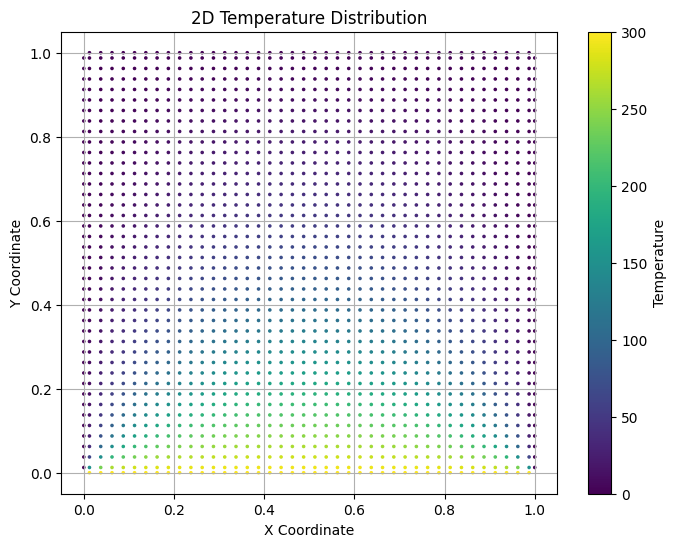

In [7]:
plot_temperature(final_T= final_T)

In [8]:
df = pandas.DataFrame(final_T, columns= ["X", "Y", "Temperature (K)"])
df.to_csv(r"D:\thesis\python\steady_centroid_temperatures.csv", sep= ",", index= False)

In [9]:
output_frame = pandas.read_csv(r"D:\thesis\python\poisson_centroid_output.csv")
#df2 = pandas.read_csv(r"D:\thesis\python\2D_SteadyState_HeatEquation.csv")
[out_X, out_Y, out_T, interpolated_T, num_L_inf, num_L2, el_vol] = [
    output_frame["X (m)"].to_numpy(), 
    output_frame["Y (m)"].to_numpy(), 
    output_frame["Temperature (K)"].to_numpy(), 
    output_frame["steady_table_vals"].to_numpy(),
    output_frame["L_inf (K)"].to_numpy(),
    output_frame["L2_err"].to_numpy(),
    output_frame["Volume (m^3)"].to_numpy()]

In [10]:
calculated_T = []
for x, y in zip(out_X,out_Y):
    if y == 0.0:
        calculated_T.append(BC)
    elif x == 0.0 or x == 1.0 or y == 1.0:
        calculated_T.append(0)
    else:
        calculated_T.append(getTemp_xy(x, y, a, b, BC))

In [11]:
#[print(x-y) for x,y in zip(interpolated_T, calculated_T)]
calculated_L2 = 0
abs_err = []
for num_T, act_T, vol in zip(out_T, calculated_T, el_vol):
    abs_err.append(numpy.abs(num_T-act_T))
    calculated_L2 += (numpy.abs(num_T-act_T)**2)*vol
    
L2_err = numpy.sqrt(calculated_L2/len(out_T))
L_inf = max(abs_err)

print('L2: ', L2_err)
print('L_inf: ', L_inf)

L2:  0.008951567666121561
L_inf:  6.579454909568938


In [12]:
reported_L2 = 0
for L2, vol in zip(num_L2, el_vol):
    reported_L2 += L2*vol
reported_L2_err = numpy.sqrt(reported_L2/len(num_L2))
print('reported L2: ', reported_L2_err)
print('reported L_inf: ', max(num_L_inf))

    

reported L2:  0.008951567666121495
reported L_inf:  6.579454909568824
